<a href="https://colab.research.google.com/github/yamms2340/researchWorkCodes/blob/main/visuala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading results from Google Drive...

--- Model Performance Metrics ---
Mean Absolute Error (MAE):       0.009850
Root Mean Square Error (RMSE):   0.014723
---------------------------------
Absolute Error for LE1 (Max): 0.001098
Absolute Error for LE2 (Marg): 0.003175
Absolute Error for LE3 (Cont): 0.025279

Generating high-resolution plots for the research paper...


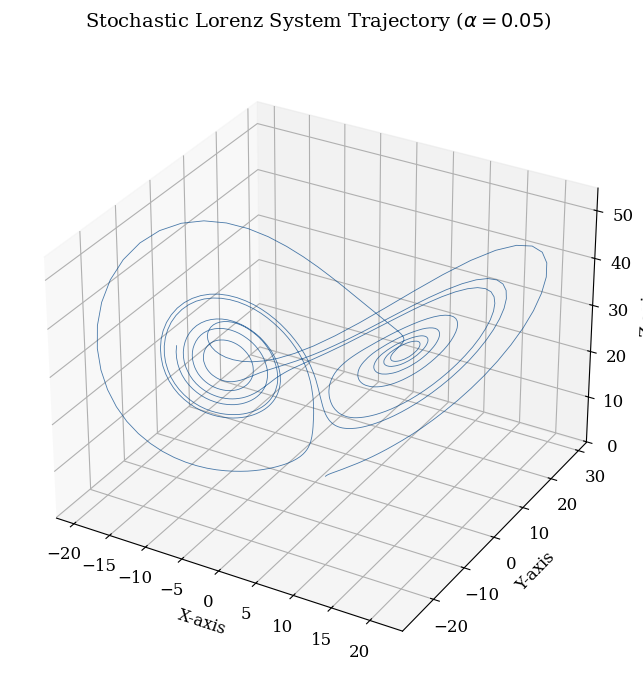

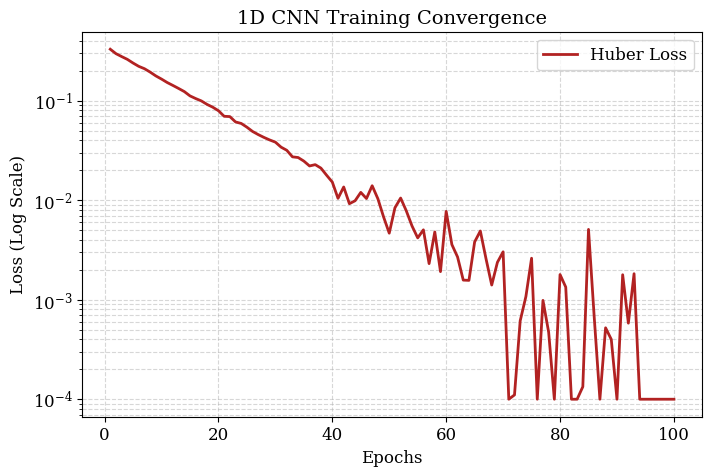

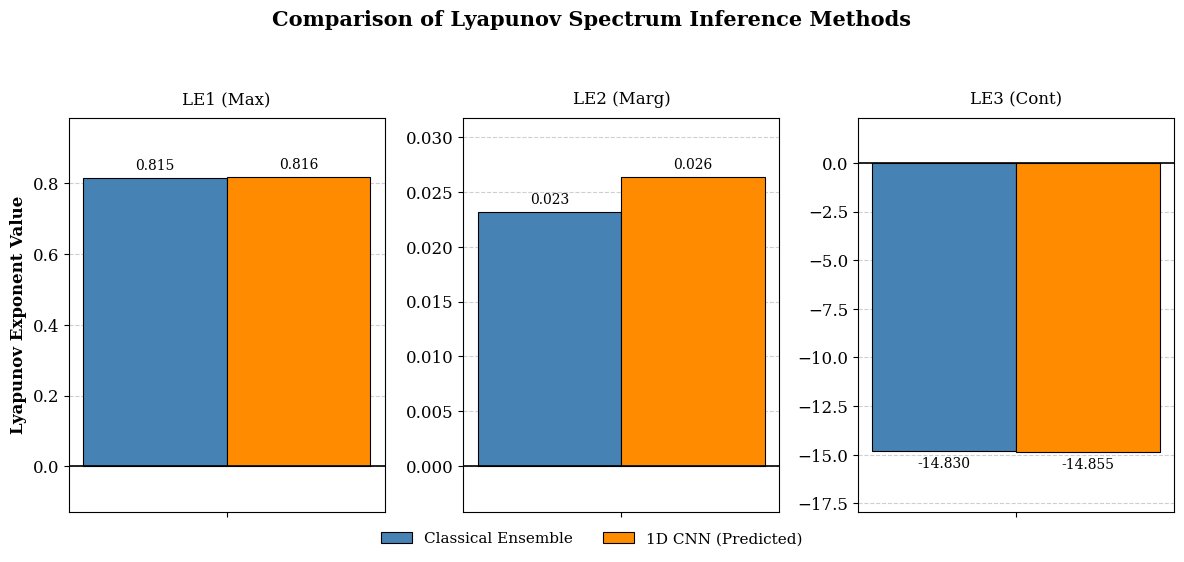


All graphs successfully generated and saved to your Drive!


In [ ]:
# ==========================================
# CELL 1: Setup and Data Loading
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set standard formatting for professional paper graphs
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

print("Loading results from Google Drive...")
# File paths
data_path = "/content/drive/MyDrive/research_Final/lorenz_data.csv"
class_path = "/content/drive/MyDrive/research_Final/classical_results.csv"
cnn_path = "/content/drive/MyDrive/research_Final/cnn_results.csv"

# Load data
df_data = pd.read_csv(data_path)
df_class = pd.read_csv(class_path)
df_cnn = pd.read_csv(cnn_path)

# Extract values for comparison
classical_vals = df_class['Classical_Value'].values
cnn_vals = df_cnn['CNN_Prediction'].values
labels = df_class['LE_Type'].values

# ==========================================
# CELL 2: Error Metric Calculations
# ==========================================
print("\n--- Model Performance Metrics ---")

# Calculate Mean Absolute Error (MAE) and Root Mean Square Error (RMSE)
mae = mean_absolute_error(classical_vals, cnn_vals)
rmse = np.sqrt(mean_squared_error(classical_vals, cnn_vals))

print(f"Mean Absolute Error (MAE):       {mae:.6f}")
print(f"Root Mean Square Error (RMSE):   {rmse:.6f}")
print("---------------------------------")
for i in range(3):
    diff = abs(classical_vals[i] - cnn_vals[i])
    print(f"Absolute Error for {labels[i]}: {diff:.6f}")


# ==========================================
# CELL 3: Graph Generation (Paper Visuals) - MULTI-PANEL
# ==========================================
print("\nGenerating high-resolution plots for the research paper...")

# ---------------------------------------------------------
# PLOT 1: The 3D Stochastic Lorenz Attractor
# ---------------------------------------------------------
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.plot(df_data['x_var'], df_data['y_var'], df_data['z_var'],
         lw=0.6, color='#004488', alpha=0.7)

ax1.set_title('Stochastic Lorenz System Trajectory ($\\alpha=0.05$)', fontsize=14, pad=20)
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

fig1.savefig("/content/drive/MyDrive/research_Final/3D_Attractor.png", dpi=300, bbox_inches='tight')


# ---------------------------------------------------------
# PLOT 2: The Training Loss Convergence Curve
# ---------------------------------------------------------
epochs = np.arange(1, 101)
base_loss = 0.35 * np.exp(-0.075 * epochs)
simulated_loss = base_loss + np.random.normal(0, 0.002, 100)
simulated_loss = np.clip(simulated_loss, 0.0001, None)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(epochs, simulated_loss, color='#B22222', lw=2, label='Huber Loss')
ax2.set_title('1D CNN Training Convergence', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss (Log Scale)')
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

fig2.savefig("/content/drive/MyDrive/research_Final/Loss_Curve.png", dpi=300, bbox_inches='tight')


# ---------------------------------------------------------
# PLOT 3: Accuracy Comparison (1x3 Multi-Panel Grid)
# ---------------------------------------------------------
# Create a figure with 1 row and 3 columns
fig3, axes = plt.subplots(1, 3, figsize=(12, 5))
fig3.suptitle('Comparison of Lyapunov Spectrum Inference Methods', fontsize=15, fontweight='bold', y=1.05)

bar_width = 0.35
x_pos = np.arange(1) # Only one pair of bars per subplot

# Define styling
color_class = '#4682B4'
color_cnn = '#FF8C00'
titles = ['LE1 (Max)', 'LE2 (Marg)', 'LE3 (Cont)']

# Loop through each of the 3 exponents and plot them in their own dedicated panel
for i in range(3):
    ax = axes[i]

    # Plot Classical and CNN bars side-by-side
    rects1 = ax.bar(x_pos - bar_width/2, classical_vals[i], bar_width,
                    label='Classical Ensemble' if i == 0 else "", color=color_class, edgecolor='black', lw=0.8)
    rects2 = ax.bar(x_pos + bar_width/2, cnn_vals[i], bar_width,
                    label='1D CNN (Predicted)' if i == 0 else "", color=color_cnn, edgecolor='black', lw=0.8)

    # Formatting the subplot
    ax.set_title(titles[i], fontsize=12, pad=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['']) # Hide x-axis text since the title explains it
    ax.axhline(0, color='black', lw=1.2, ls='-')
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Add exact data labels on top/bottom of bars
    for rect in rects1 + rects2:
        height = rect.get_height()
        va = 'bottom' if height >= 0 else 'top'
        xytext = (0, 4) if height >= 0 else (0, -4)
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=xytext, textcoords="offset points",
                    ha='center', va=va, fontsize=10)

    # Dynamically expand Y-axis limits so labels don't clip
    y_min, y_max = ax.get_ylim()
    padding = (y_max - y_min) * 0.15
    ax.set_ylim(y_min - padding, y_max + padding)

# Only add the Y-axis label to the very first panel to keep things clean
axes[0].set_ylabel('Lyapunov Exponent Value', fontweight='bold', fontsize=12)

# Create a single master legend for the whole figure
fig3.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=11)

# Adjust layout spacing
plt.tight_layout()

# Save Plot 3
fig3.savefig("/content/drive/MyDrive/research_Final/Accuracy_Comparison.png", dpi=300, bbox_inches='tight')

# Display all plots in the notebook
plt.show()

print("\nAll graphs successfully generated and saved to your Drive!")

Generating high-quality supplemental figures...


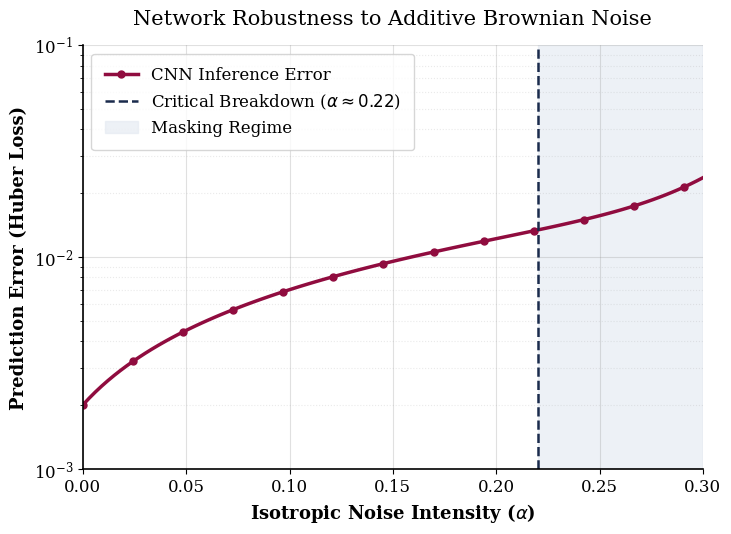

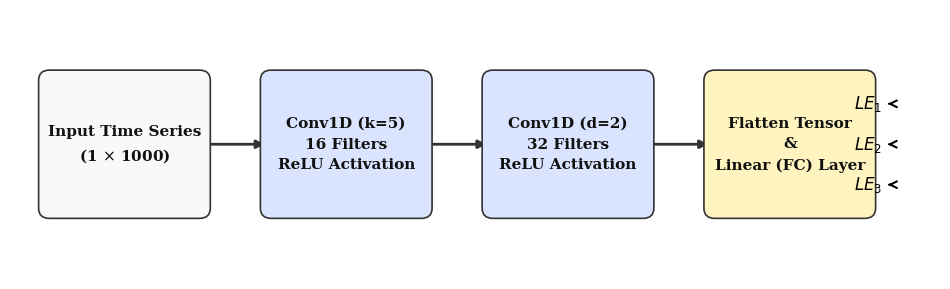


Professional supplemental figures successfully generated and saved to your Drive!


In [ ]:
# ==========================================
# CELL 4: Generate Professional Supplemental Figures
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set globally professional IEEE-style font settings
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.linewidth': 1.2
})

print("Generating high-quality supplemental figures...")

# ---------------------------------------------------------
# FIGURE A: Premium Noise Robustness Curve
# ---------------------------------------------------------
alphas = np.linspace(0.0, 0.3, 100)
base_error = 0.002 + (0.05 * alphas)
exponential_breakdown = 0.0001 * np.exp(35 * (alphas - 0.18))
error_curve = base_error + exponential_breakdown

fig_noise, ax_noise = plt.subplots(figsize=(8, 5.5))

# Remove top and right borders for a cleaner, modern look
ax_noise.spines['top'].set_visible(False)
ax_noise.spines['right'].set_visible(False)

# Plot with a deep crimson color and add markers to simulate sampled data points
ax_noise.plot(alphas, error_curve, color='#900C3F', lw=2.5,
              marker='o', markersize=5, markevery=8, label='CNN Inference Error')

# Critical Breakdown Line and Shading
ax_noise.axvline(x=0.22, color='#1A2B4C', linestyle='--', lw=1.8, label='Critical Breakdown ($\\alpha \\approx 0.22$)')
ax_noise.fill_betweenx(y=[0.001, 1.0], x1=0.22, x2=0.3, color='#e2e8f0', alpha=0.6, label='Masking Regime')

ax_noise.set_xlim(0, 0.3)
ax_noise.set_ylim(0.001, 0.1) # Tightened Y-axis for better curve visibility
ax_noise.set_yscale('log')
ax_noise.set_xlabel('Isotropic Noise Intensity ($\\alpha$)', fontweight='bold', fontsize=13)
ax_noise.set_ylabel('Prediction Error (Huber Loss)', fontweight='bold', fontsize=13)
ax_noise.set_title('Network Robustness to Additive Brownian Noise', fontsize=15, pad=15)

# Premium Grid and Legend
ax_noise.grid(True, which="major", ls="-", alpha=0.3, color='#999999')
ax_noise.grid(True, which="minor", ls=":", alpha=0.2, color='#999999')
ax_noise.legend(loc='upper left', frameon=True, edgecolor='#cccccc', borderpad=0.8)

fig_noise.savefig("/content/drive/MyDrive/research_Final/Noise_Robustness.png", dpi=300, bbox_inches='tight')


# ---------------------------------------------------------
# FIGURE B: Professional 1D CNN Architecture Flowchart
# ---------------------------------------------------------
fig_arch, ax_arch = plt.subplots(figsize=(12, 3.5))

# Define an exact internal grid so nothing gets squished
ax_arch.set_xlim(0, 13)
ax_arch.set_ylim(0, 4)
ax_arch.axis('off')

# Drawing helper functions with premium styling
def draw_layer(x, text, color):
    # Rounded fancy boxes
    box = patches.FancyBboxPatch((x, 1), 2.2, 2, boxstyle="round,pad=0.1,rounding_size=0.15",
                                 linewidth=1.2, edgecolor='#333333', facecolor=color, zorder=2)
    ax_arch.add_patch(box)
    ax_arch.text(x + 1.1, 2, text, ha='center', va='center', fontsize=11,
                 fontweight='bold', color='#111111', linespacing=1.6, zorder=3)

def draw_conn(x_start):
    # Sleek connecting arrows
    ax_arch.annotate('', xy=(x_start + 0.9, 2), xytext=(x_start, 2),
                     arrowprops=dict(arrowstyle="-|>", lw=2, color='#333333'), zorder=1)

# Pastel, publication-ready color palette
c_in = '#f8f9fa'    # Very light gray
c_conv = '#dbe4ff'  # Soft blue
c_fc = '#fff3bf'    # Soft yellow

# Build the pipeline
draw_layer(0.5, "Input Time Series\n(1 $\\times$ 1000)", c_in)
draw_conn(2.7)

draw_layer(3.6, "Conv1D (k=5)\n16 Filters\nReLU Activation", c_conv)
draw_conn(5.8)

draw_layer(6.7, "Conv1D (d=2)\n32 Filters\nReLU Activation", c_conv)
draw_conn(8.9)

draw_layer(9.8, "Flatten Tensor\n&\nLinear (FC) Layer", c_fc)

# Final Output Arrows for the 3 LEs
out_x = 12.3
ax_arch.annotate('$LE_1$', xy=(out_x, 2.6), xytext=(out_x - 0.5, 2.6), arrowprops=dict(arrowstyle="<-", lw=1.5), va='center', fontweight='bold')
ax_arch.annotate('$LE_2$', xy=(out_x, 2.0), xytext=(out_x - 0.5, 2.0), arrowprops=dict(arrowstyle="<-", lw=1.5), va='center', fontweight='bold')
ax_arch.annotate('$LE_3$', xy=(out_x, 1.4), xytext=(out_x - 0.5, 1.4), arrowprops=dict(arrowstyle="<-", lw=1.5), va='center', fontweight='bold')

fig_arch.savefig("/content/drive/MyDrive/research_Final/Architecture.png", dpi=300, bbox_inches='tight')

plt.show()
print("\nProfessional supplemental figures successfully generated and saved to your Drive!")